<a href="https://colab.research.google.com/github/utkarshg1/DeepLearning-6th-July/blob/main/Restaurant_Reviews_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment analysis
 (also called opinion mining) is the process of using natural language processing (NLP) and machine learning to determine whether a piece of text expresses a positive, negative, or neutral emotion. It helps businesses and researchers understand customer opinions, brand reputation, and emotional tone in large volumes of text such as reviews, social media posts, and surveys.

Applications:

Customer feedback analysis

Brand reputation monitoring

Product development insights

Competitor comparison

Marketing campaign evaluation

#Recurrent Neural Networks (RNNs)
are a type of neural network designed to handle sequential data, such as time-series data and text data. Unlike traditional neural networks, RNNs have a unique architecture that allows them to maintain a hidden state, which acts as a memory of previous inputs. This hidden state enables RNNs to capture temporal dependencies and make predictions based on past information.


Training RNNs involves using a technique called Backpropagation Through Time (BPTT). This method involves unrolling the RNN over time and applying backpropagation to update the weights. The loss function is calculated based on the difference between the predicted output and the actual output, and the error is propagated back through the network to update the weights.

#Advantages:
RNNs can remember previous inputs, making them suitable for time-series prediction and other sequential data tasks.

#Disadvantages:
RNNs suffer from vanishing and exploding gradient problems, making training difficult.

# Sentiment Analysis with Keras

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

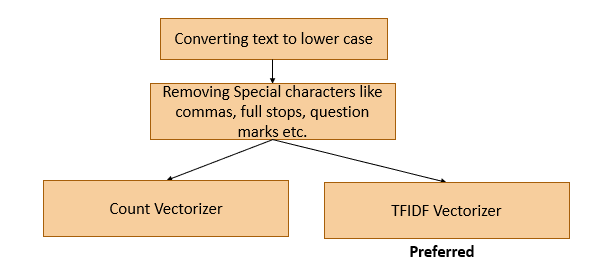

### Step 1: Read the dataset

In [1]:
import pandas as pd
df = pd.read_csv('/content/Restaurant_Reviews.csv')
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good. ## $%,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


In [ ]:
### provide proper pattern [^a-z<space>]

### Create a function to preprocess text

In [2]:
import re
def preprocess_text(s):
  s = s.lower()
  s = re.sub("[^a-z ]", "", s)
  return s

In [3]:
a = "Wow'... 5@, The expericence was very good"
preprocess_text(a)

'wow  the expericence was very good'

### Apply preprocessing on dataframe

In [4]:
df['Review_pre'] = df['Review'].apply(preprocess_text)

In [5]:
df

,Review,Liked,Review_pre
0,Wow... Loved this place.,1,wow loved this place
1,Crust is not good. ## $%,0,crust is not good
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...
...,...,...,...
995,I think food should have flavor and texture an...,0,i think food should have flavor and texture an...
996,Appetite instantly gone.,0,appetite instantly gone
997,Overall I was not impressed and would not go b...,0,overall i was not impressed and would not go back
998,"The whole experience was underwhelming, and I ...",0,the whole experience was underwhelming and i t...


In [6]:
# Preprocessing the Text
#Tokenize and pad sequences so all reviews have equal length.
#we’re preparing our text data (tokenized as numbers) so that all sentences have the same length
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
X = df['Review_pre'].values
y = df['Liked'].values

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)
padded = pad_sequences(sequences, maxlen=25, padding='post')
#[maxlen=20] Each input sequence (sentence) will be exactly 20 tokens long.
#"Padding" means where to add the zeros.['post' → pad after the sequence]

| Original Text                                                     | Tokenized Sequence                     | Result (maxlen=20)                                                      |
| ----------------------------------------------------------------- | -------------------------------------- | ----------------------------------------------------------------------- |
| "I love this restaurant"                                          | `[12, 45, 78, 133]`                    | `[12, 45, 78, 133, 0, 0, 0, …]` (adds zeros till length = 20)           |
| "The food was absolutely delicious and the service was excellent" | `[8, 55, 22, 120, 98, 4, 8, 300, 450]` | `[8, 55, 22, 120, 98, 4, 8, 300, 450, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]` |




The padded_sample_sequence is what you would pass to the Embedding layer of your first RNN model. The Embedding layer then converts these integers into dense vectors.

Multiple Embedding layers: These are typically used when you have multiple distinct text inputs (e.g., a review and a product description) that you want to embed separately.


An "embedding" in machine learning, especially in Natural Language Processing (NLP), is a dense vector representation of discrete data (like words, categories, or entities) into a continuous vector space.


1] Sequential Embeddings (for LSTM Model): This involves preprocessing the text, then tokenizing it into numerical sequences, and finally padding these sequences to a fixed length. These padded sequences are then fed into the Keras Embedding layer which learns dense vector representations for each word.


2] TF-IDF Vectors (for Dense Layer Model): This involves preprocessing the text and then converting it into TF-IDF (Term Frequency-Inverse Document Frequency) vectors, which are numerical representations highlighting the importance of words in a document relative to a corpus.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(padded, y, test_size=0.1, random_state=42)

# Build the model
model = Sequential([
    Embedding(input_dim=5000, output_dim=80, input_length=25),
    LSTM(70),       #LSTM is a type of recurrent neural network designed to capture long-term dependencies in sequential data by using memory cells and gates to control information flow.
    Dense(1, activation='sigmoid')])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Embedding Layer :Converts words (represented as integers) into dense vectors of real numbers that capture their meaning.

input_dim=5000 → Vocabulary size (number of unique words)

output_dim=64 → Embedding vector size for each word

input_length=20 → Length of each input sentence (after padding)

 LSTM Layer
:Purpose:

LSTM (Long Short-Term Memory) processes the sequence of word embeddings in order and captures context and dependencies between words.

Example:

“The food was good”
“The food was not good”

The word “not” changes the meaning — LSTM remembers previous words and adjusts understanding dynamically.

*** Keeps track of what to remember or forget using gates:

Forget Gate → What old info to drop

Input Gate → What new info to add

Output Gate → What to send to next layer

Output:

After processing the full sentence, LSTM outputs either:

The final hidden state (summary of sentence)

Or all hidden states (for each word — used in seq2seq models)

## Dense Layer
Purpose:

Performs final classification or regression based on the sentence representation produced by the LSTM.

In [8]:
# train the model
model.fit(X_train, y_train, epochs=50, batch_size=5, validation_data=(X_test, y_test))


Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5100 - loss: 0.6955 - val_accuracy: 0.4600 - val_loss: 0.6946
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7067 - loss: 0.5653 - val_accuracy: 0.7400 - val_loss: 0.5678
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9056 - loss: 0.2760 - val_accuracy: 0.7700 - val_loss: 0.5273
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9522 - loss: 0.1530 - val_accuracy: 0.7400 - val_loss: 0.9871
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9578 - loss: 0.1400 - val_accuracy: 0.7500 - val_loss: 0.7856
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9744 - loss: 0.0844 - val_accuracy: 0.7500 - val_loss: 0.8464
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9844 - loss: 0.0638 - val_accuracy: 0.7500 - val_loss: 0.8862
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9911 - loss: 0.0378 - val_accuracy: 0.

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7500 - loss: 2.0510 
Test Accuracy: 0.75


In [13]:
#sample_review = ["The food was good and staff were friendly!"]
sample_review = ["The food was not good."]

seq = tokenizer.texts_to_sequences(sample_review)
padded_seq = pad_sequences(seq, maxlen=25, padding='post')

pred = model.predict(padded_seq)
print("Positive" if pred[0][0] > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Negative


In [ ]:
pred

array([[3.851956e-06]], dtype=float32)

### Apply TFIDF Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_pre = tfidf.fit_transform(df['Review_pre']).toarray()

In [ ]:
X_pre

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X_pre.shape

(1000, 2043)

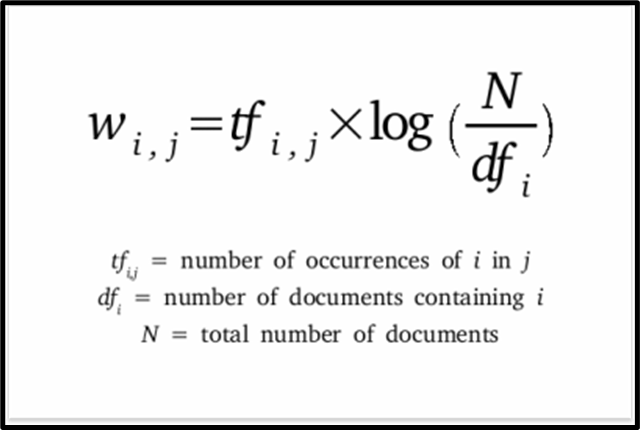

In [ ]:
Y = df['Liked']

### Apply Train test split

In [ ]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X_pre, Y, test_size=0.1, random_state=21)

In [ ]:
xtrain.shape

(900, 2043)

In [ ]:
xtest.shape

(100, 2043)

### Build The Neural Net

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()

# Input Layer
model.add(Input(shape=(xtrain.shape[1],)))
#xtrain.shape[1] represents the number of features in the training data xtrain. This determines the size of the input layer.
#Example: If xtrain has 100 features (columns), the input layer expects a vector of length 100.

# Hidden Layer 1
model.add(Dense(256, activation='relu'))
# Dropout Layer 1
model.add(Dropout(0.3))
# Regularization technique to prevent overfitting.
#Dropout Layer: first dropout layer, 30% of neurons are ignored during training to enhance generalization.

# Hidden Layer 2
model.add(Dense(200, activation='relu'))
# Dropout layer 2
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))
#The final layer has 1 neuron because this is likely a binary classification task.
#Each input from the previous layer is connected to this single output neuron.
#Activation Function (sigmoid):
#Squashes the output to a value between 0 and 1, which is ideal for binary classification (e.g., predicting probabilities).

#Use Case :
This model could be used for binary classification tasks such as spam detection, sentiment analysis, or fraud detection.

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       523,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        51,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 574,865 (2.19 MB)

 Trainable params: 574,865 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Summary
Use the Adam optimizer to adjust weights.
Minimize the binary cross-entropy loss, which is well-suited for binary classification tasks.
Track accuracy as a measure of how well the model performs during training and evaluation.

In [ ]:
es = EarlyStopping(patience=20)

Early stopping is a technique to prevent overfitting during training by halting the process once the model stops improving on a validation dataset.
##patience=10:
Specifies how many epochs to wait for an improvement before stopping the training.

In [ ]:
hist = model.fit(xtrain, ytrain,
                 validation_split=0.2,
                 batch_size=16,
                 epochs=50,
                 callbacks=[es])

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5134 - loss: 0.6894 - val_accuracy: 0.5889 - val_loss: 0.6774
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7832 - loss: 0.6230 - val_accuracy: 0.7778 - val_loss: 0.5326
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9444 - loss: 0.3066 - val_accuracy: 0.7611 - val_loss: 0.4383
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9958 - loss: 0.0659 - val_accuracy: 0.7333 - val_loss: 0.5565
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0233 - val_accuracy: 0.7444 - val_loss: 0.5452
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - loss: 0.0088 - val_accuracy: 0.7556 - val_loss: 0.6178
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 0.0080 - val_accuracy: 0.7500 - val_loss: 0.6082
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9983 - loss: 0.0084 - val_accuracy: 0.7500 - val_loss

### Learning curve

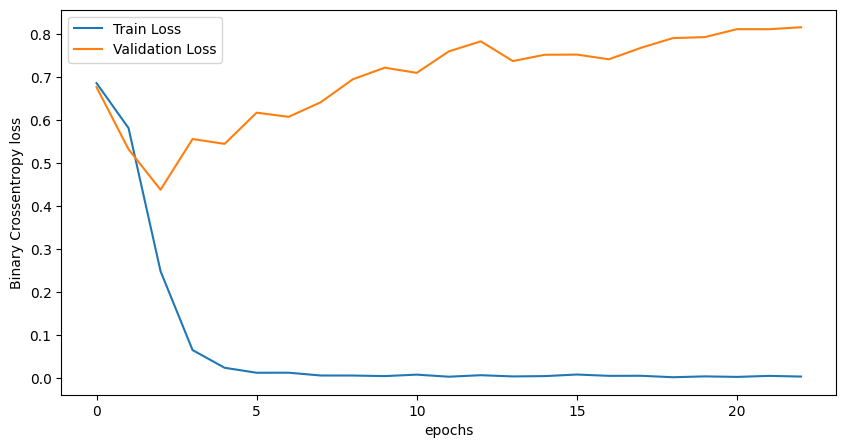

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.xlabel('epochs')
plt.ylabel('Binary Crossentropy loss')
plt.legend()
plt.show()

### Evaluate the model

In [ ]:
model.evaluate(xtrain, ytrain)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9902 - loss: 0.0327


[0.1657765805721283, 0.949999988079071]

In [ ]:
model.evaluate(xtest, ytest)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8909 - loss: 0.3055 


[0.3616040050983429, 0.8600000143051147]

### Predict results for train and test

In [ ]:
yprob_train = model.predict(xtrain)
yprob_test = model.predict(xtest)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
yprob_train[0:5]

array([[9.9999738e-01],
       [7.1145507e-04],
       [9.9997306e-01],
       [9.9965775e-01],
       [3.9787896e-04]], dtype=float32)

In [ ]:
ypred_train = [1 if prob>=0.5 else 0 for prob in yprob_train]
ypred_test = [1 if prob>=0.5 else 0 for prob in yprob_test]

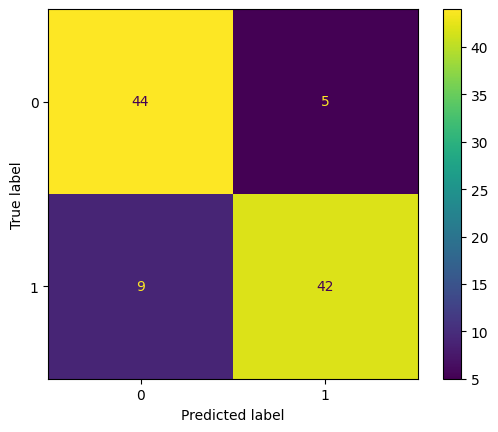

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(ytest, ypred_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred_test))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86        49
           1       0.89      0.82      0.86        51

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100



### Save the model for future use

In [ ]:
model.save("SentimentModel.keras")

### Load the model

In [ ]:
from keras.models import load_model

In [ ]:
nn = load_model("/content/SentimentModel.keras")
nn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       523,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        51,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,724,597 (6.58 MB)

 Trainable params: 574,865 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,149,732 (4.39 MB)

### Out of sample prediction

In [ ]:
s = "Very tasty food"
t = tfidf.transform([s]).toarray()
t

array([[0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
model.predict(t)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


array([[0.9940661]], dtype=float32)

In [ ]:
def predict_sentiment():
  text = input("Please enter restuaraunt review : ")
  text = preprocess_text(text)
  text_pre = tfidf.transform([text]).toarray()
  prob = model.predict(text_pre)
  if prob>=0.5:
    print("Positive Review")
  else:
    print("Negative Review")
  return prob

In [ ]:
predict_sentiment()

Please enter restuaraunt review : food quality was good
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Positive Review


array([[0.6198694]], dtype=float32)

In [ ]:
predict_sentiment()

Please enter restuaraunt review : food quality was not good
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Negative Review


array([[5.643466e-05]], dtype=float32)

In [ ]:
#!pip install textblob # Make sure textblob is installed
import nltk
nltk.download('movie_reviews')
nltk.download('punkt_tab') # Download the missing 'punkt_tab' resource

from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer

df= "\" How Asia's densest slum contained the virus and the economic catastrophe that stares at the hardworking slum population..'\""
df2="Bad Taste, I did not like the taste of Pizza here"
df3=" Very tasty food"
df4="Wow... Loved this place."
# Applying the NaiveBayesAnalyzer
blob_object = TextBlob(df4, analyzer=NaiveBayesAnalyzer())
# Running sentiment analysis
analysis = blob_object.sentiment
print(analysis)

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Sentiment(classification='pos', p_pos=0.538861471083953, p_neg=0.4611385289160466)
